In [3]:
import os
import json
import random
import warnings

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import f1_score, accuracy_score
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

print("SECTION 1: ENVIRONMENT CHECK")

if torch.cuda.is_available():
    device = torch.device("cuda")
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
    print(f"GPU detected: {gpu_name}")
    print(f"VRAM: {gpu_mem:.1f} GB")
else:
    device = torch.device("cpu")
    print("WARNING: No GPU detected. The MLPs are small so CPU will still work, "
          "but the Section 3 embedding extraction pass through MentalBERT will be slow on CPU.")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Load HF token from Kaggle Secrets (needed to download MentalBERT in Section 2)
try:
    from kaggle_secrets import UserSecretsClient
    secrets = UserSecretsClient()
    HF_TOKEN = secrets.get_secret("HF_TOKEN")
    print("HF_TOKEN loaded from Kaggle Secrets.")
except Exception as e:
    HF_TOKEN = os.environ.get("HF_TOKEN")
    if HF_TOKEN:
        print("HF_TOKEN loaded from environment variable.")
    else:
        print(f"WARNING: Could not load HF_TOKEN: {e}")
        print("MentalBERT requires authentication. Add HF_TOKEN as a Kaggle Secret.")

CHECKPOINT_DIR = "/kaggle/working/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print(f"Checkpoint directory: {CHECKPOINT_DIR}")

SECTION 1: ENVIRONMENT CHECK
GPU detected: Tesla T4
VRAM: 14.6 GB
PyTorch version: 2.10.0+cu128
Device: cuda
HF_TOKEN loaded from Kaggle Secrets.
Checkpoint directory: /kaggle/working/checkpoints


In [4]:
import os

print("===== INPUT DATASETS =====")
for root, dirs, files in os.walk("/kaggle/input"):
    print(root)
    if len(files):
        print("  Files:", files[:10], "..." if len(files) > 10 else "")
    print()

===== INPUT DATASETS =====
/kaggle/input

/kaggle/input/datasets

/kaggle/input/datasets/sxmsxmsxm

/kaggle/input/datasets/sxmsxmsxm/audio-embeddings

/kaggle/input/datasets/sxmsxmsxm/audio-embeddings/audio
  Files: ['422.npy', '331.npy', '461.npy', '375.npy', '308.npy', '330.npy', 'dev_ids.npy', '464.npy', '407.npy', '491.npy'] ...

/kaggle/input/datasets/sxmsxmsxm/official-splits

/kaggle/input/datasets/sxmsxmsxm/official-splits/splits
  Files: ['dev.csv', 'class_weights.csv', 'train.csv', 'test.csv'] 

/kaggle/input/datasets/sxmsxmsxm/transcript

/kaggle/input/datasets/sxmsxmsxm/transcript/transcript_clean
  Files: ['361.txt', '431.txt', '487.txt', '372.txt', '333.txt', '351.txt', '418.txt', '449.txt', '464.txt', '375.txt'] ...

/kaggle/input/models

/kaggle/input/models/sxmsxmsxm

/kaggle/input/models/sxmsxmsxm/best-joint-checkpoint-pt

/kaggle/input/models/sxmsxmsxm/best-joint-checkpoint-pt/pytorch

/kaggle/input/models/sxmsxmsxm/best-joint-checkpoint-pt/pytorch/best_joint_checkpo

In [5]:
print("SECTION 2: LOAD PHASE 4 JOINT MODEL")

JOINT_CKPT_DIR = (
    "/kaggle/input/models/sxmsxmsxm/"
    "best-joint-checkpoint-pt/pytorch/"
    "best_joint_checkpoint/1"
)

JOINT_CKPT_PATH = os.path.join(JOINT_CKPT_DIR, "best_joint_checkpoint.pt")


class JointModel(nn.Module):
    '''Shared MentalBERT backbone with Head 1 (condition, 5-class) and Head 2 (cause, 6-class).
    Must match the Phase 4 training notebook's class definition exactly.'''

    def __init__(self, backbone, num_condition=5, num_cause=6, dropout_rate=0.1):
        super().__init__()
        self.backbone = backbone
        self.dropout = nn.Dropout(dropout_rate)
        self.head1_classifier = nn.Linear(768, num_condition)
        self.head2_classifier = nn.Linear(768, num_cause)

    def forward(self, input_ids, attention_mask):
        outputs = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        pooled = outputs.pooler_output                 # 768-dim, shared by both heads
        pooled_dropped = self.dropout(pooled)
        condition_logits = self.head1_classifier(pooled_dropped)
        cause_logits = self.head2_classifier(pooled_dropped)
        return condition_logits, cause_logits, pooled   # raw pooled returned for embedding extraction


print("Loading MentalBERT backbone (architecture only; weights come from the checkpoint next)...")
backbone = AutoModel.from_pretrained("mental/mental-bert-base-uncased", token=HF_TOKEN)
joint_model = JointModel(backbone, num_condition=5, num_cause=6, dropout_rate=0.1).to(device)

print(f"Loading joint checkpoint from {JOINT_CKPT_PATH} ...")
joint_checkpoint = torch.load(JOINT_CKPT_PATH, map_location=device, weights_only=False)
joint_model.load_state_dict(joint_checkpoint["model_state_dict"])
joint_model.eval()
print("Joint model loaded and set to eval mode (frozen — Phase 5 does not fine-tune the backbone further).")

for key in ("val_head1_macro_f1", "val_head2_macro_f1", "val_macro_f1", "epoch"):
    if key in joint_checkpoint:
        print(f"  checkpoint[{key!r}] = {joint_checkpoint[key]}")

tokenizer = AutoTokenizer.from_pretrained("mental/mental-bert-base-uncased", token=HF_TOKEN)
print("Tokenizer loaded.")

SECTION 2: LOAD PHASE 4 JOINT MODEL
Loading MentalBERT backbone (architecture only; weights come from the checkpoint next)...


config.json:   0%|          | 0.00/639 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: mental/mental-bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your d

...

tokenizer_config.json:   0%|          | 0.00/321 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Tokenizer loaded.


In [6]:
print("SECTION 3 (PHASE 5a): RE-EXTRACT DAIC-WOZ TEXT EMBEDDINGS FROM JOINT BACKBONE")

import glob

TRANSCRIPTS_DIR = "/kaggle/input/datasets/sxmsxmsxm/transcript/transcript_clean"  
TEXT_EMB_MAX_LENGTH = 256   # match Phase 1 / 2 / 4 tokenization

txt_files = sorted(glob.glob(os.path.join(TRANSCRIPTS_DIR, "*.txt")))
print(f"Found {len(txt_files)} cleaned transcript files under {TRANSCRIPTS_DIR}")

rows = []
for path in txt_files:
    pid = os.path.splitext(os.path.basename(path))[0]   # "361.txt" -> "361"
    with open(path, "r", encoding="utf-8") as f:
        text = f.read().strip()
    if not text:
        print(f"  [{pid}] WARNING: empty file, skipping")
        continue
    rows.append({"participant_id": pid, "transcript_text": text})

transcripts_df = pd.DataFrame(rows).sort_values("participant_id").reset_index(drop=True)
transcripts_df["participant_id"] = transcripts_df["participant_id"].astype(str)
print(f"Loaded {len(transcripts_df)} transcripts. Columns: {list(transcripts_df.columns)}")

TEXT_EMB_OUT_DIR = "/kaggle/working/daic-woz-embeddings/text"
os.makedirs(TEXT_EMB_OUT_DIR, exist_ok=True)


def extract_text_embedding(text, tokenizer, model, device, max_length=256):
    '''Tokenize one transcript and return its 768-dim pooled embedding from the joint backbone.'''
    encoding = tokenizer(
        str(text), max_length=max_length, padding="max_length",
        truncation=True, return_tensors="pt",
    ).to(device)
    with torch.no_grad():
        _, _, pooled = model(encoding["input_ids"], encoding["attention_mask"])
    return pooled.squeeze(0).cpu().numpy()


n_saved = 0
for row in tqdm(transcripts_df.itertuples(), total=len(transcripts_df), desc="Extracting text embeddings"):
    pid = row.participant_id
    emb = extract_text_embedding(row.transcript_text, tokenizer, joint_model, device, TEXT_EMB_MAX_LENGTH)
    np.save(os.path.join(TEXT_EMB_OUT_DIR, f"{pid}.npy"), emb)
    n_saved += 1

print(f"Extracted and saved {n_saved} text embeddings (768-dim) to {TEXT_EMB_OUT_DIR}")

SECTION 3 (PHASE 5a): RE-EXTRACT DAIC-WOZ TEXT EMBEDDINGS FROM JOINT BACKBONE
Found 187 cleaned transcript files under /kaggle/input/datasets/sxmsxmsxm/transcript/transcript_clean
Loaded 187 transcripts. Columns: ['participant_id', 'transcript_text']


Extracting text embeddings:   0%|          | 0/187 [00:00<?, ?it/s]

Extracted and saved 187 text embeddings (768-dim) to /kaggle/working/daic-woz-embeddings/text


In [7]:
import os

print("Directory exists:", os.path.exists("/kaggle/working/daic-woz-embeddings/text"))

Directory exists: True


In [8]:
print("SECTION 4: ASSEMBLE TRAIN/DEV/TEST FEATURE + LABEL ARRAYS")

AUDIO_EMB_DIR = "/kaggle/input/datasets/sxmsxmsxm/audio-embeddings/audio"
SPLITS_DIR = "/kaggle/input/datasets/sxmsxmsxm/official-splits/splits"


def load_split(split_name):
    split_path = os.path.join(SPLITS_DIR, f"{split_name}.csv")
    split_df = pd.read_csv(split_path)   # expects columns: participant_id, phq8_binary
    split_df["participant_id"] = split_df["participant_id"].astype(str)

    text_X, audio_X, y, pids, missing = [], [], [], [], []
    for row in split_df.itertuples():
        pid = row.participant_id
        text_path = os.path.join(TEXT_EMB_OUT_DIR, f"{pid}.npy")
        audio_path = os.path.join(AUDIO_EMB_DIR, f"{pid}.npy")
        if not (os.path.exists(text_path) and os.path.exists(audio_path)):
            missing.append(pid)
            continue
        text_X.append(np.load(text_path))
        audio_X.append(np.load(audio_path))
        y.append(int(row.phq8_binary))
        pids.append(pid)

    if missing:
        print(f"  WARNING: {split_name} missing embeddings for {len(missing)} participants: {missing}")

    return np.stack(text_X), np.stack(audio_X), np.array(y, dtype=np.int64), pids


train_text_X, train_audio_X, train_y, train_pids = load_split("train")
dev_text_X, dev_audio_X, dev_y, dev_pids = load_split("dev")
test_text_X, test_audio_X, test_y, test_pids = load_split("test")

for name, X_t, X_a, y in [("Train", train_text_X, train_audio_X, train_y),
                           ("Dev", dev_text_X, dev_audio_X, dev_y),
                           ("Test", test_text_X, test_audio_X, test_y)]:
    print(f"{name}: {len(y)} participants | text {X_t.shape} | audio {X_a.shape} | "
          f"depressed={int(y.sum())} not_depressed={int((y == 0).sum())}")

SECTION 4: ASSEMBLE TRAIN/DEV/TEST FEATURE + LABEL ARRAYS
Train: 107 participants | text (107, 768) | audio (107, 768) | depressed=30 not_depressed=77
Dev: 33 participants | text (33, 768) | audio (33, 768) | depressed=12 not_depressed=21
Test: 47 participants | text (47, 768) | audio (47, 768) | depressed=14 not_depressed=33


In [9]:
print("SECTION 5: EMBEDDING DATASET & DATALOADERS")

class EmbeddingDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return {"embedding": self.X[idx], "label": self.y[idx]}


BATCH_SIZE = 16   # small on purpose -- train split is only 107 participants


def make_loaders(train_X, dev_X, test_X, train_y, dev_y, test_y):
    train_loader = DataLoader(EmbeddingDataset(train_X, train_y), batch_size=BATCH_SIZE, shuffle=True)
    dev_loader = DataLoader(EmbeddingDataset(dev_X, dev_y), batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(EmbeddingDataset(test_X, test_y), batch_size=BATCH_SIZE, shuffle=False)
    return train_loader, dev_loader, test_loader


text_train_loader, text_dev_loader, text_test_loader = make_loaders(
    train_text_X, dev_text_X, test_text_X, train_y, dev_y, test_y
)
audio_train_loader, audio_dev_loader, audio_test_loader = make_loaders(
    train_audio_X, dev_audio_X, test_audio_X, train_y, dev_y, test_y
)
print("DataLoaders ready for both branches.")

SECTION 5: EMBEDDING DATASET & DATALOADERS
DataLoaders ready for both branches.


In [10]:
print("SECTION 6: DEPRESSION MLP CLASS")

class DepressionMLP(nn.Module):
    '''768-dim embedding -> 256 -> 128 intermediate features -> 1 auxiliary binary output.
    The 128-dim features (not the aux logit) are what Phase 6 fusion consumes.'''

    def __init__(self, input_dim=768, hidden_dim=256, feature_dim=128, dropout_rate=0.4):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, feature_dim),
            nn.ReLU(),
        )
        self.aux_head = nn.Linear(feature_dim, 1)

    def forward(self, x):
        features = self.encoder(x)                      # (batch, 128) -- kept for fusion
        logits = self.aux_head(features).squeeze(-1)     # (batch,) -- this branch's own loss only
        return logits, features


print("DepressionMLP defined. Will be instantiated once for text, once for audio.")

SECTION 6: DEPRESSION MLP CLASS
DepressionMLP defined. Will be instantiated once for text, once for audio.


In [11]:
print("SECTION 7: TRAINING FUNCTION")

def compute_pos_weight(y):
    pos = y.sum()
    neg = len(y) - pos
    return torch.tensor(neg / max(pos, 1), dtype=torch.float32)


def evaluate_mlp(model, loader, device):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            x = batch["embedding"].to(device)
            y = batch["label"].to(device)
            logits, _ = model(x)
            probs = torch.sigmoid(logits)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    preds = (all_probs >= 0.5).astype(int)
    f1 = f1_score(all_labels, preds, average="macro", zero_division=0)
    acc = accuracy_score(all_labels, preds)
    return f1, acc, preds, all_labels, all_probs


def train_depression_mlp(branch_name, train_loader, dev_loader, train_y,
                          input_dim=768, max_epochs=60, lr=1e-3, patience=10,
                          weight_decay=1e-3, checkpoint_dir=CHECKPOINT_DIR):
    model = DepressionMLP(input_dim=input_dim).to(device)
    pos_weight = compute_pos_weight(train_y).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    print(f"\n--- Training {branch_name} MLP ---")
    print(f"pos_weight (class imbalance correction): {pos_weight.item():.3f}")

    best_f1 = 0.0
    best_epoch = 0
    patience_counter = 0
    ckpt_path = os.path.join(checkpoint_dir, f"{branch_name.lower()}_mlp_checkpoint.pt")
    history = {"epoch": [], "train_loss": [], "dev_macro_f1": [], "dev_accuracy": []}

    for epoch in range(1, max_epochs + 1):
        model.train()
        total_loss, n_batches = 0.0, 0
        for batch in train_loader:
            x = batch["embedding"].to(device)
            y = batch["label"].to(device)
            optimizer.zero_grad()
            logits, _ = model(x)
            loss = criterion(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
            n_batches += 1
        avg_loss = total_loss / n_batches

        dev_f1, dev_acc, _, _, _ = evaluate_mlp(model, dev_loader, device)
        history["epoch"].append(epoch)
        history["train_loss"].append(avg_loss)
        history["dev_macro_f1"].append(dev_f1)
        history["dev_accuracy"].append(dev_acc)

        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d} | train_loss={avg_loss:.4f} | dev_macro_f1={dev_f1:.4f} | dev_acc={dev_acc:.4f}")

        if dev_f1 > best_f1:
            best_f1 = dev_f1
            best_epoch = epoch
            patience_counter = 0
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "dev_macro_f1": dev_f1,
                "dev_accuracy": dev_acc,
                "input_dim": input_dim,
            }, ckpt_path)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  Early stopping at epoch {epoch} (no dev improvement for {patience} epochs)")
                break

    print(f"Best {branch_name} dev macro F1: {best_f1:.4f} at epoch {best_epoch}")
    return ckpt_path, history, best_f1

SECTION 7: TRAINING FUNCTION


In [12]:
print("SECTION 8a (PHASE 5b): TRAIN TEXT DEPRESSION MLP")
text_ckpt_path, text_history, text_best_dev_f1 = train_depression_mlp(
    "Text", text_train_loader, text_dev_loader, train_y, input_dim=768
)

print("\nSECTION 8b (PHASE 5c): TRAIN AUDIO DEPRESSION MLP")
audio_ckpt_path, audio_history, audio_best_dev_f1 = train_depression_mlp(
    "Audio", audio_train_loader, audio_dev_loader, train_y, input_dim=768
)

SECTION 8a (PHASE 5b): TRAIN TEXT DEPRESSION MLP

--- Training Text MLP ---
pos_weight (class imbalance correction): 2.567
  Epoch   1 | train_loss=1.0039 | dev_macro_f1=0.5460 | dev_acc=0.6061
  Epoch   5 | train_loss=0.9501 | dev_macro_f1=0.4978 | dev_acc=0.5758
  Epoch  10 | train_loss=0.8515 | dev_macro_f1=0.5417 | dev_acc=0.5758
  Early stopping at epoch 13 (no dev improvement for 10 epochs)
Best Text dev macro F1: 0.5662 at epoch 3

SECTION 8b (PHASE 5c): TRAIN AUDIO DEPRESSION MLP

--- Training Audio MLP ---
pos_weight (class imbalance correction): 2.567
  Epoch   1 | train_loss=0.9967 | dev_macro_f1=0.2667 | dev_acc=0.3636
  Epoch   5 | train_loss=0.9930 | dev_macro_f1=0.3889 | dev_acc=0.6364
  Epoch  10 | train_loss=0.9917 | dev_macro_f1=0.6118 | dev_acc=0.7273
  Epoch  15 | train_loss=0.9705 | dev_macro_f1=0.6827 | dev_acc=0.6970
  Epoch  20 | train_loss=0.9908 | dev_macro_f1=0.5935 | dev_acc=0.6667
  Epoch  25 | train_loss=0.9366 | dev_macro_f1=0.5935 | dev_acc=0.6667
  Earl

In [13]:
print("SECTION 9: STANDALONE TEST EVALUATION (TEXT-ONLY AND AUDIO-ONLY)")

def load_best_mlp(ckpt_path, input_dim=768):
    model = DepressionMLP(input_dim=input_dim).to(device)
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    return model, ckpt


text_model, text_ckpt = load_best_mlp(text_ckpt_path)
audio_model, audio_ckpt = load_best_mlp(audio_ckpt_path)

text_test_f1, text_test_acc, *_ = evaluate_mlp(text_model, text_test_loader, device)
audio_test_f1, audio_test_acc, *_ = evaluate_mlp(audio_model, audio_test_loader, device)

print(f"Text-only  test macro F1: {text_test_f1:.4f} | accuracy: {text_test_acc:.4f}")
print(f"Audio-only test macro F1: {audio_test_f1:.4f} | accuracy: {audio_test_acc:.4f}")

results_path = os.path.join(CHECKPOINT_DIR, "phase5_unimodal_results.txt")
with open(results_path, "w") as f:
    f.write("PHASE 5: UNIMODAL DEPRESSION MLP RESULTS\n")
    f.write("=" * 50 + "\n\n")
    f.write(f"Text MLP  - best dev epoch {text_ckpt['epoch']}, dev macro F1 {text_ckpt['dev_macro_f1']:.4f}\n")
    f.write(f"Text MLP  - test macro F1 {text_test_f1:.4f}, test accuracy {text_test_acc:.4f}\n\n")
    f.write(f"Audio MLP - best dev epoch {audio_ckpt['epoch']}, dev macro F1 {audio_ckpt['dev_macro_f1']:.4f}\n")
    f.write(f"Audio MLP - test macro F1 {audio_test_f1:.4f}, test accuracy {audio_test_acc:.4f}\n")
print(f"Results saved to {results_path}")

SECTION 9: STANDALONE TEST EVALUATION (TEXT-ONLY AND AUDIO-ONLY)
Text-only  test macro F1: 0.5761 | accuracy: 0.6383
Audio-only test macro F1: 0.4960 | accuracy: 0.5106
Results saved to /kaggle/working/checkpoints/phase5_unimodal_results.txt


In [18]:
print("SECTION 9A: COMPREHENSIVE TEST EVALUATION")

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
)
import numpy as np
import os


def predict_model(model, loader, device):
    model.eval()

    probs = []
    labels = []

    with torch.no_grad():
        for batch in loader:
            x = batch["embedding"].to(device)
            y = batch["label"].cpu().numpy()

            logits, _ = model(x)
            p = torch.sigmoid(logits).cpu().numpy()

            probs.extend(p)
            labels.extend(y)

    probs = np.array(probs)
    labels = np.array(labels).astype(int)
    preds = (probs >= 0.5).astype(int)

    return labels, preds, probs


def compute_metrics(y_true, y_pred, y_prob):

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall/Sensitivity": sensitivity,
        "Specificity": specificity,
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "Confusion Matrix": np.array([[tn, fp], [fn, tp]])
    }

    return metrics


def bootstrap_ci(y_true, y_pred, y_prob, n_boot=1000):

    rng = np.random.default_rng(42)

    stats = {
        "Accuracy": [],
        "Macro F1": [],
        "Sensitivity": [],
        "Specificity": [],
        "ROC-AUC": []
    }

    N = len(y_true)

    for _ in range(n_boot):

        idx = rng.integers(0, N, N)

        yt = y_true[idx]
        yp = y_pred[idx]
        pr = y_prob[idx]

        if len(np.unique(yt)) < 2:
            continue

        tn, fp, fn, tp = confusion_matrix(yt, yp).ravel()

        stats["Accuracy"].append(
            accuracy_score(yt, yp)
        )

        stats["Macro F1"].append(
            f1_score(yt, yp, average="macro", zero_division=0)
        )

        stats["Sensitivity"].append(
            tp / (tp + fn) if (tp + fn) else 0
        )

        stats["Specificity"].append(
            tn / (tn + fp) if (tn + fp) else 0
        )

        stats["ROC-AUC"].append(
            roc_auc_score(yt, pr)
        )

    ci = {}

    for k, values in stats.items():
        ci[k] = (
            np.percentile(values, 2.5),
            np.percentile(values, 97.5)
        )

    return ci


def evaluate_branch(name, model, loader):

    print("\n" + "="*70)
    print(name.upper())
    print("="*70)

    y_true, y_pred, y_prob = predict_model(model, loader, device)

    metrics = compute_metrics(y_true, y_pred, y_prob)

    print("\nConfusion Matrix")
    print(metrics["Confusion Matrix"])

    print("\nMetrics")

    for k in [
        "Accuracy",
        "Precision",
        "Recall/Sensitivity",
        "Specificity",
        "Macro F1",
        "Weighted F1",
        "Balanced Accuracy",
        "ROC-AUC",
    ]:
        print(f"{k:22s}: {metrics[k]:.4f}")

    print("\nClassification Report\n")
    print(classification_report(y_true, y_pred, digits=4))

    ci = bootstrap_ci(y_true, y_pred, y_prob)

    print("\n95% Bootstrap Confidence Intervals")

    for k, (lo, hi) in ci.items():
        print(f"{k:15s}: [{lo:.4f}, {hi:.4f}]")

    return metrics


text_metrics = evaluate_branch(
    "TEXT MODEL",
    text_model,
    text_test_loader
)

audio_metrics = evaluate_branch(
    "AUDIO MODEL",
    audio_model,
    audio_test_loader
)

print("\nEvaluation complete.")

SECTION 9A: COMPREHENSIVE TEST EVALUATION

TEXT MODEL

Confusion Matrix
[[24  9]
 [ 8  6]]

Metrics
Accuracy              : 0.6383
Precision             : 0.4000
Recall/Sensitivity    : 0.4286
Specificity           : 0.7273
Macro F1              : 0.5761
Weighted F1           : 0.6418
Balanced Accuracy     : 0.5779
ROC-AUC               : 0.5671

Classification Report

              precision    recall  f1-score   support

           0     0.7500    0.7273    0.7385        33
           1     0.4000    0.4286    0.4138        14

    accuracy                         0.6383        47
   macro avg     0.5750    0.5779    0.5761        47
weighted avg     0.6457    0.6383    0.6418        47


95% Bootstrap Confidence Intervals
Accuracy       : [0.4894, 0.7660]
Macro F1       : [0.4152, 0.7157]
Sensitivity    : [0.1663, 0.6667]
Specificity    : [0.5756, 0.8846]
ROC-AUC        : [0.3658, 0.7482]

AUDIO MODEL

Confusion Matrix
[[16 17]
 [ 6  8]]

Metrics
Accuracy              : 0.5106
Preci

## Section 10: Training Curves

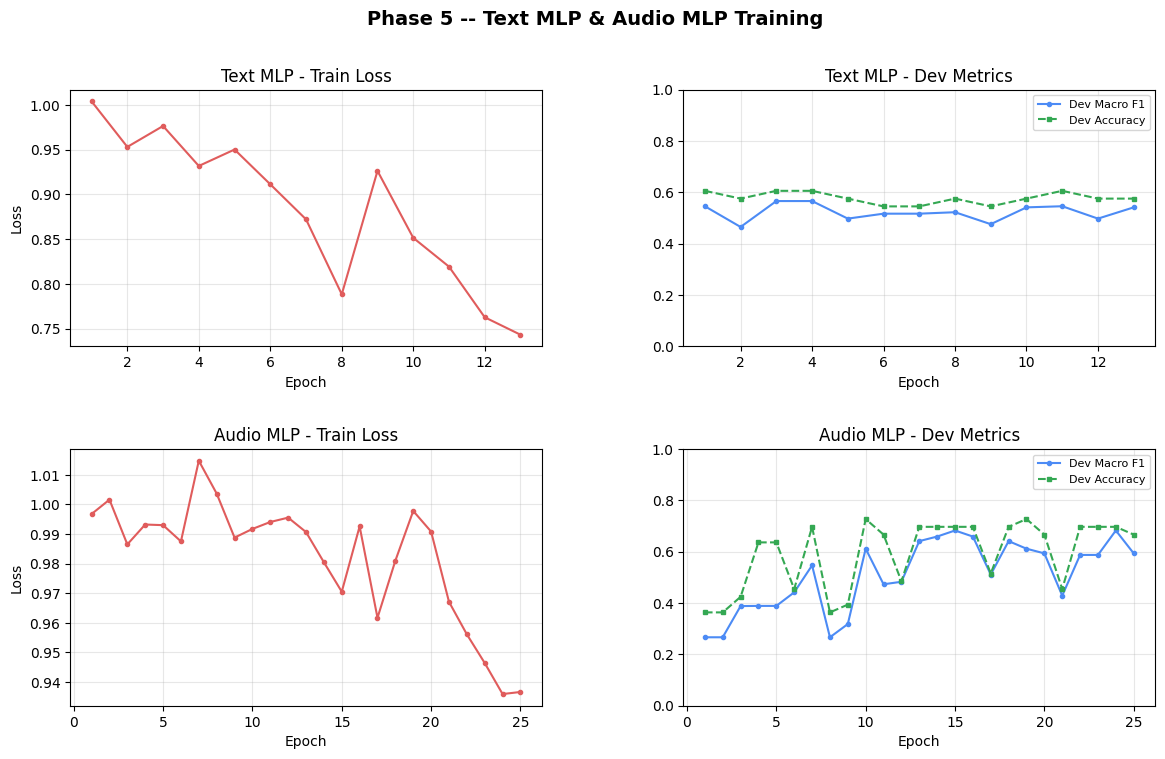

Plot saved to checkpoints/phase5_training_curves.png


In [14]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(14, 8))
fig.suptitle("Phase 5 -- Text MLP & Audio MLP Training", fontsize=14, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(text_history["epoch"], text_history["train_loss"], "o-", color="#e05c5c", markersize=3)
ax1.set_title("Text MLP - Train Loss")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(text_history["epoch"], text_history["dev_macro_f1"], "o-", color="#4c8bf5", markersize=3, label="Dev Macro F1")
ax2.plot(text_history["epoch"], text_history["dev_accuracy"], "s--", color="#34a853", markersize=3, label="Dev Accuracy")
ax2.set_title("Text MLP - Dev Metrics")
ax2.set_xlabel("Epoch"); ax2.set_ylim(0, 1); ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(audio_history["epoch"], audio_history["train_loss"], "o-", color="#e05c5c", markersize=3)
ax3.set_title("Audio MLP - Train Loss")
ax3.set_xlabel("Epoch"); ax3.set_ylabel("Loss"); ax3.grid(True, alpha=0.3)

ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(audio_history["epoch"], audio_history["dev_macro_f1"], "o-", color="#4c8bf5", markersize=3, label="Dev Macro F1")
ax4.plot(audio_history["epoch"], audio_history["dev_accuracy"], "s--", color="#34a853", markersize=3, label="Dev Accuracy")
ax4.set_title("Audio MLP - Dev Metrics")
ax4.set_xlabel("Epoch"); ax4.set_ylim(0, 1); ax4.legend(fontsize=8); ax4.grid(True, alpha=0.3)

plt.savefig(os.path.join(CHECKPOINT_DIR, "phase5_training_curves.png"), dpi=120, bbox_inches="tight")
plt.show()
print("Plot saved to checkpoints/phase5_training_curves.png")

In [16]:
print("SECTION 11: EXTRACT 128-DIM INTERMEDIATE FEATURES FOR PHASE 6 FUSION")

FEATURES_OUT_DIR = "/kaggle/working/phase5_intermediate_features"
os.makedirs(FEATURES_OUT_DIR, exist_ok=True)


def extract_features(model, X, device):
    model.eval()
    with torch.no_grad():
        x = torch.tensor(X, dtype=torch.float32).to(device)
        _, features = model(x)
    return features.cpu().numpy()


for split_name, text_X, audio_X, y, pids in [
    ("train", train_text_X, train_audio_X, train_y, train_pids),
    ("dev", dev_text_X, dev_audio_X, dev_y, dev_pids),
    ("test", test_text_X, test_audio_X, test_y, test_pids),
]:
    text_feats = extract_features(text_model, text_X, device)     # (n, 128)
    audio_feats = extract_features(audio_model, audio_X, device)  # (n, 128)

    np.save(os.path.join(FEATURES_OUT_DIR, f"{split_name}_text_features.npy"), text_feats)
    np.save(os.path.join(FEATURES_OUT_DIR, f"{split_name}_audio_features.npy"), audio_feats)
    np.save(os.path.join(FEATURES_OUT_DIR, f"{split_name}_labels.npy"), y)
    with open(os.path.join(FEATURES_OUT_DIR, f"{split_name}_participant_ids.json"), "w") as f:
        json.dump(pids, f)

    print(f"{split_name}: text_features {text_feats.shape}, audio_features {audio_feats.shape}, "
          f"labels {y.shape}")

print(f"\nAll intermediate features saved to {FEATURES_OUT_DIR}")
print("These text_features.npy + audio_features.npy arrays (128-dim each) are exactly")
print("what Phase 6's Fusion MLP (concat(128+128) -> 64 -> 1) will load and train on.")

SECTION 11: EXTRACT 128-DIM INTERMEDIATE FEATURES FOR PHASE 6 FUSION
train: text_features (107, 128), audio_features (107, 128), labels (107,)
dev: text_features (33, 128), audio_features (33, 128), labels (33,)
test: text_features (47, 128), audio_features (47, 128), labels (47,)

All intermediate features saved to /kaggle/working/phase5_intermediate_features
These text_features.npy + audio_features.npy arrays (128-dim each) are exactly
what Phase 6's Fusion MLP (concat(128+128) -> 64 -> 1) will load and train on.


## Section 12: Package and Download

In [17]:
print("=" * 60)
print("OUTPUT FILES")
print("=" * 60)

for d in [CHECKPOINT_DIR, TEXT_EMB_OUT_DIR, FEATURES_OUT_DIR]:
    print(f"\n{d}:")
    for fname in sorted(os.listdir(d)):
        fpath = os.path.join(d, fname)
        if os.path.isfile(fpath):
            size_mb = os.path.getsize(fpath) / (1024 * 1024)
            print(f"  {fname}  ({size_mb:.2f} MB)")

import shutil
from IPython.display import FileLink, display

PACKAGE_DIR = "/kaggle/working/phase5_package"
os.makedirs(PACKAGE_DIR, exist_ok=True)
shutil.copytree(CHECKPOINT_DIR, os.path.join(PACKAGE_DIR, "checkpoints"), dirs_exist_ok=True)
shutil.copytree(FEATURES_OUT_DIR, os.path.join(PACKAGE_DIR, "intermediate_features"), dirs_exist_ok=True)
shutil.copytree(TEXT_EMB_OUT_DIR, os.path.join(PACKAGE_DIR, "text_embeddings_joint"), dirs_exist_ok=True)

zip_path = "/kaggle/working/phase5_outputs"
shutil.make_archive(zip_path, "zip", PACKAGE_DIR)
zip_full_path = zip_path + ".zip"

size_mb = os.path.getsize(zip_full_path) / (1024 * 1024)
print(f"\nZipped all Phase 5 outputs to: {zip_full_path} ({size_mb:.2f} MB)")
display(FileLink(zip_full_path))

print("\nAll done. Download from the Output tab on Kaggle.")

OUTPUT FILES

/kaggle/working/checkpoints:
  audio_mlp_checkpoint.pt  (2.64 MB)
  phase5_training_curves.png  (0.13 MB)
  phase5_unimodal_results.txt  (0.00 MB)
  text_mlp_checkpoint.pt  (2.64 MB)

/kaggle/working/daic-woz-embeddings/text:
  300.npy  (0.00 MB)
  301.npy  (0.00 MB)
  302.npy  (0.00 MB)
  303.npy  (0.00 MB)
  304.npy  (0.00 MB)
  305.npy  (0.00 MB)
  306.npy  (0.00 MB)
  307.npy  (0.00 MB)
  308.npy  (0.00 MB)
  309.npy  (0.00 MB)
  310.npy  (0.00 MB)
  311.npy  (0.00 MB)
  312.npy  (0.00 MB)
  313.npy  (0.00 MB)
  314.npy  (0.00 MB)
  315.npy  (0.00 MB)
  316.npy  (0.00 MB)
  317.npy  (0.00 MB)
  318.npy  (0.00 MB)
  319.npy  (0.00 MB)
  320.npy  (0.00 MB)
  321.npy  (0.00 MB)
  322.npy  (0.00 MB)
  323.npy  (0.00 MB)
  324.npy  (0.00 MB)
  325.npy  (0.00 MB)
  326.npy  (0.00 MB)
  327.npy  (0.00 MB)
  328.npy  (0.00 MB)
  329.npy  (0.00 MB)
  330.npy  (0.00 MB)
  331.npy  (0.00 MB)
  332.npy  (0.00 MB)
  333.npy  (0.00 MB)
  334.npy  (0.00 MB)
  335.npy  (0.00 MB)
  33

/kaggle/working/phase5_outputs.zip


All done. Download from the Output tab on Kaggle.
